# ECG Signal Analysis

**Author:** Yevhen Skyba\
Computer Engineering Student @ Wrocław University of Science and Technology

## Scope

1. ECG data loading and visualization
2. FFT-based frequency analysis
3. Inverse FFT reconstruction
4. ECG spectrum analysis
5. Butterworth digital filtering

## Background

An electrocardiogram (ECG) is a recording of the electrical activity of the heart over time. The ECG signal is an analog signal that, after sampling at a frequency \($f_s$\), takes the form of a discrete signal — a sequence of samples representing the electrical voltage measured by the electrodes.

Basic parameters of an ECG signal:

* **Sampling frequency \($f_s$\)** — the number of samples per second [Hz]
* **Amplitude** — electrical voltage [mV]
* **Lead** — a pair of electrodes measuring the potential difference

Three files containing ECG signals were used in the exercise:

* `ekg1.txt` — 12 leads, \($f_s$ = 1000\) Hz
* `ekg100.txt` — 1 lead, \($f_s$ = 360\) Hz
* `ekg_noise.txt` — 1 lead with noise, \($f_s$ = 360\) Hz (format: time, amplitude)


Used libraries: `numpy`, `matplotlib`, `scipy`.

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

OUTPUT_DIR = "./outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "task1_results"), exist_ok=True)

def save_figure(filename):
    path = os.path.join(OUTPUT_DIR, f"{filename}.png")
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {path}")
    plt.show()
    plt.close()


---

### Dataset 1 - ``ekg1.txt``

The file contains 12 columns corresponding to the 12 ECG leads and 5000 rows of samples. The sampling frequency is $f_s$ = 1000 Hz, which means that the signal duration is 5 seconds.

The signal duration is calculated automatically from the number of samples and the sampling frequency. The time axis is generated using `np.arange()` with a step of $\frac{1}{f_s}$. A logical mask is then used to select the requested time interval. The mask is an array of `True`/`False` values indicating which samples belong to the specified interval.

The `channeling` variable determines which ECG lead is displayed. The selected interval is also exported both as all 12 leads and as the selected lead only.

Saved figure: ./outputs\ecg_ekg1.png


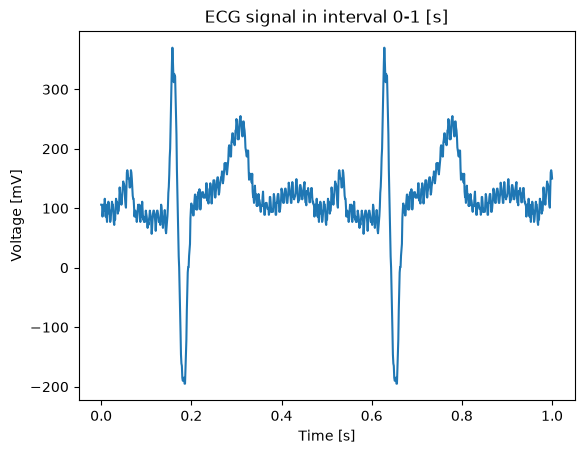

In [33]:
ekg = np.loadtxt('./signals/ekg1.txt')

t_start = 0
t_end = 1
fs = 1000

channeling = 0

duration = ekg.shape[0] / fs
time = np.arange(0, duration, 1/fs)
mask = (time >= t_start) & (time <= t_end)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [mV]")
plt.title(f"ECG signal in interval {t_start}-{t_end} [s]")
plt.plot(time[mask], ekg[mask, channeling])

np.savetxt(f"./outputs/task1_results/ekg1-{t_start}-{t_end}-wszystkie.txt", np.column_stack((time[mask], ekg[mask, :])))
np.savetxt(f"./outputs/task1_results/ekg1-{t_start}-{t_end}-odprowadzenie.txt", np.column_stack((time[mask], ekg[mask, channeling])))

save_figure("ecg_ekg1")

### Dataset 2 - `ekg100.txt`

The file contains a single ECG lead represented by one column of amplitude values. The sampling frequency is \($f_s$ = 360\) Hz, and the complete signal lasts approximately 1805 seconds.

Compared with `ekg1.txt`, the main difference is that the loaded array is one-dimensional. Therefore, the signal is accessed using `ekg[mask]` instead of `ekg[mask, channel]`. The sampling frequency is also changed to 360 Hz when constructing the time axis.

Saved figure: ./outputs\ecg_ekg100.png


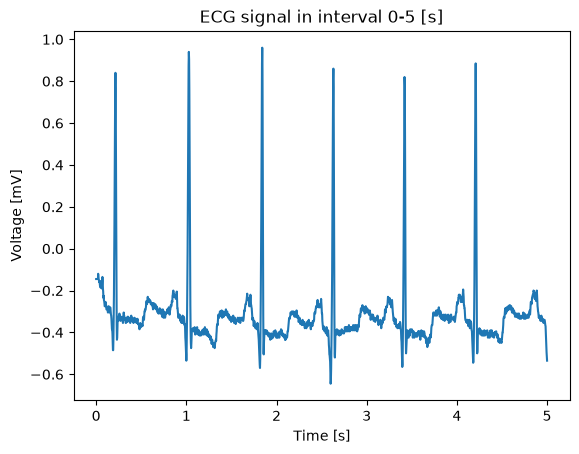

In [34]:
ekg = np.loadtxt('./signals/ekg100.txt')

t_start = 0
t_end = 5
fs = 360

duration = ekg.shape[0] / fs
time = np.arange(0, duration, 1/fs)
mask = (time >= t_start) & (time <= t_end)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [mV]")
plt.title(f"ECG signal in interval {t_start}-{t_end} [s]")
plt.plot(time[mask], ekg[mask])

np.savetxt(f"./outputs/task1_results/ekg100-{t_start}-{t_end}.txt", np.column_stack((time[mask], ekg[mask])))

save_figure("ecg_ekg100")

### Dataset 3 - `ekg_noise.txt`

The file contains two columns: the first column contains time values in seconds, while the second column contains the ECG amplitude in millivolts. The sampling frequency is $f_s$ = 360 Hz.

In this case, the time axis is not generated using `np.arange()`. Instead, it is read directly from the first column of the file. The ECG amplitude is obtained from the second column. The same type of logical mask is then used to select the requested time interval.

Saved figure: ./outputs\ecg_noisy.png


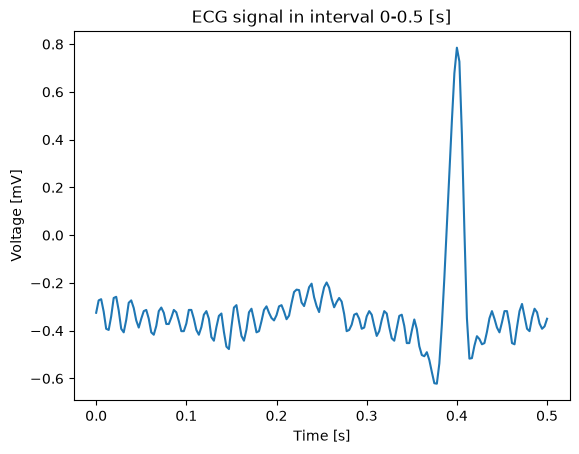

In [35]:
ekg = np.loadtxt('./signals/ekg_noise.txt')

t_start = 0
t_end = 0.5
fs = 360

duration = ekg.shape[0] / fs
time = ekg[:, 0]
mask = (time >= t_start) & (time <= t_end)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [mV]")
plt.title(f"ECG signal in interval {t_start}-{t_end} [s]")
plt.plot(time[mask], ekg[mask, 1])

np.savetxt(f"./outputs/task1_results/ekg-noise-{t_start}-{t_end}.txt", np.column_stack((time[mask], ekg[mask])))

save_figure("ecg_noisy")

---

The experiments use NumPy FFT routines to identify frequency components, study sampling effects, and reconstruct signals with the inverse FFT.

### 2.1 Generate a 50 Hz Sine Wave

A sinusoidal signal with a frequency of $f$ = 50 Hz is generated using a sampling frequency of $f_s$ = 1000 Hz. The signal contains $N$ = 65536 samples and is described by the equation:

$$
y(t) = \sin(2\pi f t)
$$

For visualization, only the interval from 0 to 0.1 seconds is displayed. Since the signal frequency is 50 Hz, this interval contains 5 complete periods of the sinusoid.

Saved figure: ./outputs\sine_wave_50hz.png


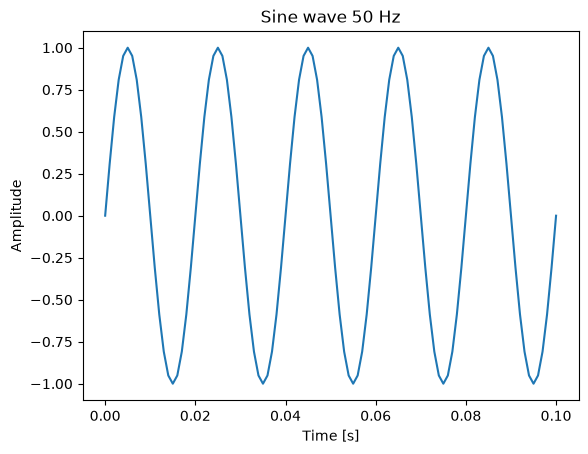

In [36]:
fs = 1000
f = 50
t = np.arange(0, 65536/fs, 1/fs)
y = np.sin(2 * np.pi * f * t)

mask = (t >= 0) & (t <= 0.1)
plt.title(f"Sine wave {f} Hz")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.plot(t[mask], y[mask])
save_figure("sine_wave_50hz")

The resulting waveform contains five complete oscillations in the displayed 0.1-second interval, as expected from the 50 Hz frequency.

### 2.2 Amplitude Spectrum of the 50 Hz Sine Wave

The discrete Fourier transform of the signal is calculated using `np.fft.fft()`. Since the FFT returns complex-valued coefficients, `np.abs()` is used to obtain their magnitudes and therefore the amplitude spectrum.

The corresponding frequency axis is generated using `np.fft.fftfreq()`. Only the non-negative frequencies are displayed because the spectrum of a real-valued signal is symmetric around zero.

Saved figure: ./outputs\spectrum_50hz.png


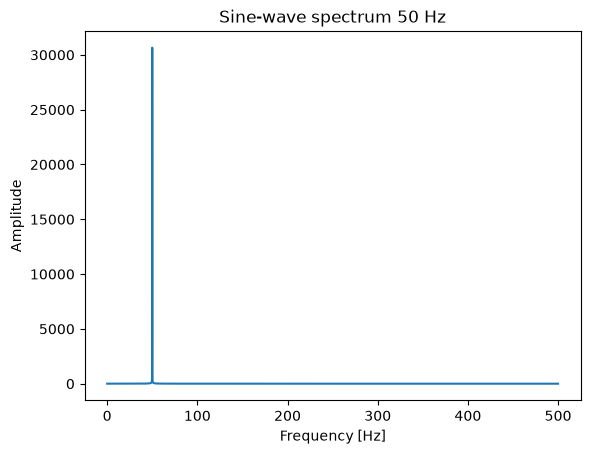

In [37]:
freqs = np.fft.fftfreq(len(y), 1/fs)
mask_freq = freqs >= 0

plt.title(f"Sine-wave spectrum {f} Hz")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(y))[mask_freq])
save_figure("spectrum_50hz")

The spectrum contains a dominant peak at 50 Hz, confirming that the generated signal consists of a single frequency component.

### 2.3 Spectrum of a Two-Frequency Signal

A signal composed of two sinusoidal components is generated:

$$
y(t) = \sin(2\pi f_1 t) + \sin(2\pi f_2 t)
$$

where $f_1$ = 50 Hz and $f_2$ = 60\ Hz.

The purpose of this experiment is to verify whether the Fourier transform can distinguish between multiple frequency components present in the same signal.

Saved figure: ./outputs\spectrum_50hz_60hz.png


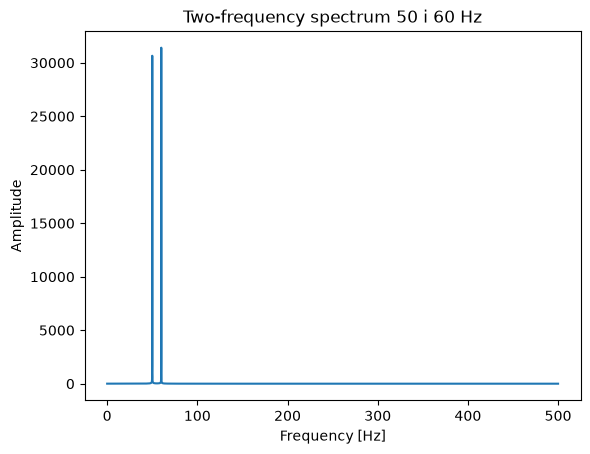

In [38]:
f1, f2 = 50, 60
y = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t)

plt.title(f"Two-frequency spectrum {f1} i {f2} Hz")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(y))[mask_freq])
save_figure("spectrum_50hz_60hz")

Two distinct peaks can be observed in the amplitude spectrum, at 50 Hz and 60 Hz. This confirms that the Fourier transform correctly separates the signal into its individual frequency components.

### 2.4 Effect of Sampling Frequency

The experiment is repeated using several sampling frequencies:

$$
f_s \in \{200,\ 500,\ 1000,\ 5000\}\text{ Hz}.
$$

The signal itself contains the same two frequency components, 50 Hz and 60 Hz. Changing the sampling frequency changes the frequency axis and the Nyquist frequency, which is equal to $f_s/2$.

The purpose of the experiment is to observe how the choice of sampling frequency affects the representation of the signal in the frequency domain.

Saved figure: ./outputs\spectrum_fs_200hz.png


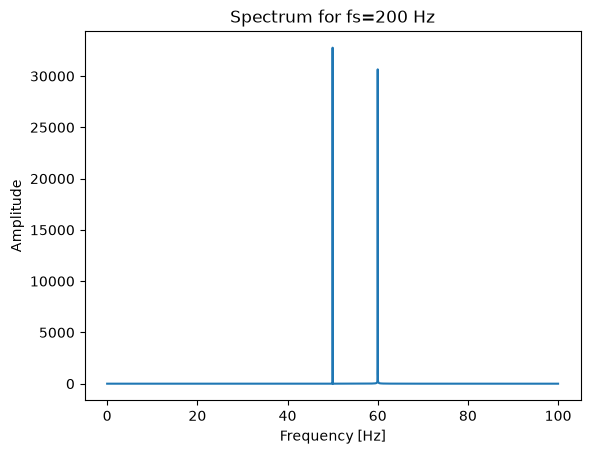

Saved figure: ./outputs\spectrum_fs_500hz.png


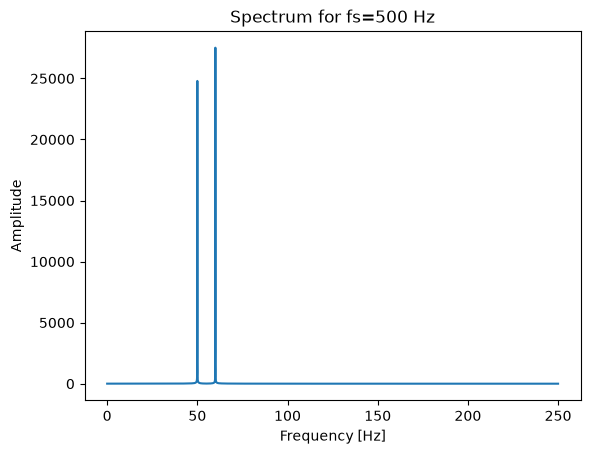

Saved figure: ./outputs\spectrum_fs_1000hz.png


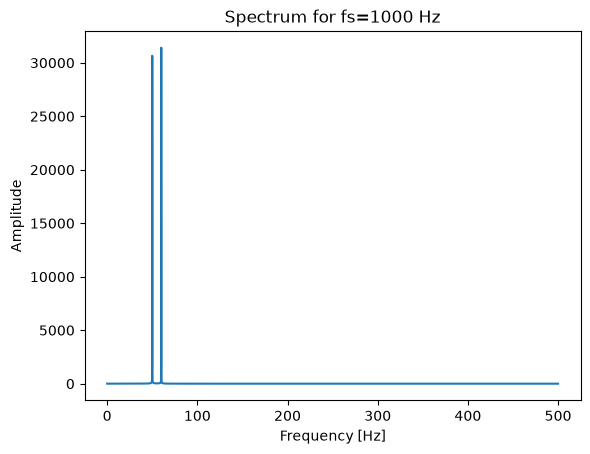

Saved figure: ./outputs\spectrum_fs_5000hz.png


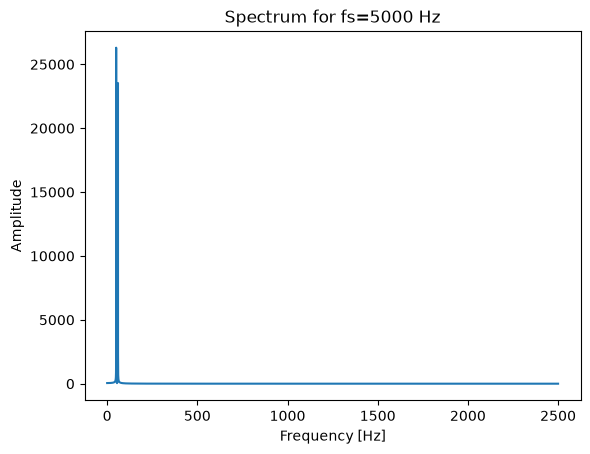

In [39]:
for fs in [200, 500, 1000, 5000]:
    t = np.arange(0, 65536/fs, 1/fs)
    y = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 60 * t)
    freqs = np.fft.fftfreq(len(y), 1/fs)
    mask_freq = freqs >= 0

    plt.figure()
    plt.title(f"Spectrum for fs={fs} Hz")
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Amplitude")
    plt.plot(freqs[mask_freq], np.abs(np.fft.fft(y))[mask_freq])
    save_figure(f"spectrum_fs_{fs}hz")

The peaks corresponding to 50 Hz and 60 Hz remain at the same physical frequencies for all sampling rates. However, the displayed frequency range changes with \(f_s\), since the positive-frequency spectrum extends up to the Nyquist frequency \(f_s/2\).

At lower sampling frequencies, the 50 Hz and 60 Hz components occupy a larger portion of the displayed frequency range. At higher sampling frequencies, they appear closer to zero relative to the full frequency axis.

### 2.5 Inverse Fourier Transform

The inverse Fourier transform is calculated using `np.fft.ifft()`. The original signal is first transformed into the frequency domain using `np.fft.fft()`, and the resulting spectrum is then transformed back into the time domain.

The reconstructed signal is compared with the original signal to verify whether the transformation preserves the signal information.

Saved figure: ./outputs\two_frequency_original_vs_reconstructed.png


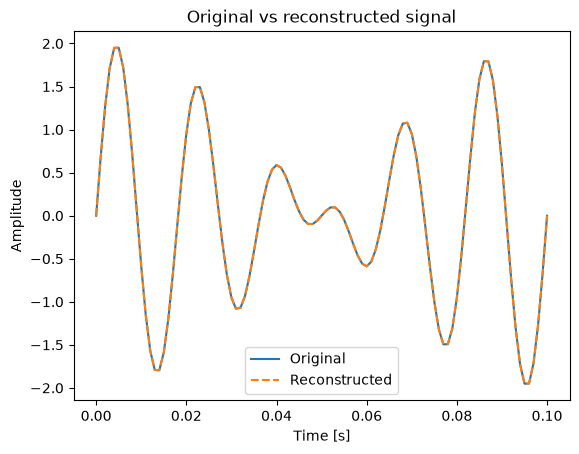

In [40]:
fs = 1000
t = np.arange(0, 65536/fs, 1/fs)
mask = (t >= 0) & (t <= 0.1)

y = np.sin(2 * np.pi * 50 * t) + np.sin(2 * np.pi * 60 * t)
Y = np.fft.fft(y)
y_odtworzone = np.fft.ifft(Y)

plt.title("Original vs reconstructed signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.plot(t[mask], y[mask], label="Original")
plt.plot(t[mask], np.real(y_odtworzone[mask]), label="Reconstructed", linestyle="--")
plt.legend()
save_figure("two_frequency_original_vs_reconstructed")

The original and reconstructed signals overlap almost perfectly. This demonstrates that the discrete Fourier transform is reversible when the complete spectrum is preserved. Any small numerical differences are caused by floating-point arithmetic.

---

### 3.1 Load and Visualize the ECG

The real ECG signal is loaded from `ekg100.txt`. The file contains a single ECG lead sampled at $f_s$ = 360 Hz.

For visualization, a 5-second segment is selected. The resulting waveform contains characteristic QRS complexes corresponding to individual heartbeats. In the displayed segment, the QRS complexes occur approximately every 0.75 seconds, corresponding to roughly 80 beats per minute.

Saved figure: ./outputs\ecg_signal.png


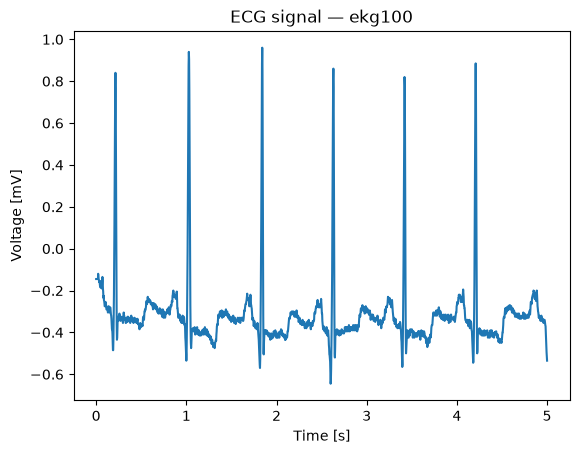

In [41]:
fs = 360
ekg = np.loadtxt('./signals/ekg100.txt')

duration = ekg.shape[0] / fs
t = np.arange(0, duration, 1/fs)
mask = (t >= 0) & (t <= 5)

plt.figure()
plt.title("ECG signal — ekg100")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [mV]")
plt.plot(t[mask], ekg[mask])
save_figure("ecg_signal")

The resulting plot shows the characteristic periodic structure of the ECG signal, including the pronounced QRS complexes associated with ventricular depolarization.

### 3.2 ECG Amplitude Spectrum

The discrete Fourier transform of the complete ECG signal is calculated and its amplitude spectrum is displayed.

Because the signal is sampled at $f_s$ = 360 Hz, the positive-frequency spectrum extends from 0 to the Nyquist frequency:

$$
f_N = \frac{f_s}{2} = 180\text{ Hz}.
$$

The spectrum makes it possible to determine which frequency components contribute most strongly to the ECG waveform.

Saved figure: ./outputs\ecg_spectrum.png


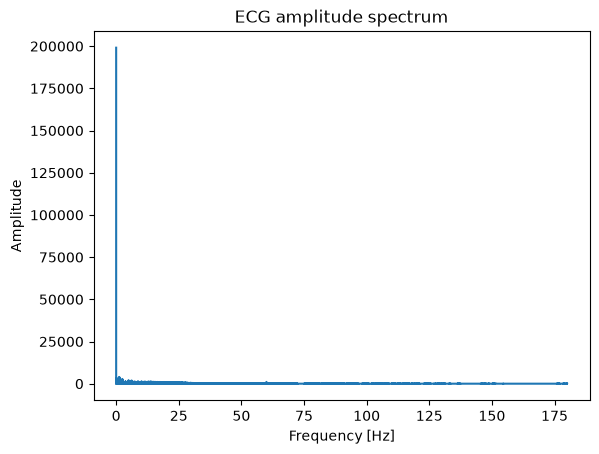

In [42]:
freqs = np.fft.fftfreq(len(ekg), 1/fs)
mask_freq = freqs >= 0

plt.figure()
plt.title("ECG amplitude spectrum")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(ekg))[mask_freq])
save_figure("ecg_spectrum")

Most of the signal energy is concentrated at low frequencies, close to 0 Hz. This is characteristic of ECG signals, which contain relatively slow variations associated with the cardiac cycle. The sharper QRS complexes also contain higher-frequency components, but their spectral amplitudes are considerably smaller.

### 3.3 Inverse FFT Reconstruction

The complete ECG spectrum is transformed back into the time domain using `np.fft.ifft()`. The reconstructed signal is compared with the original ECG signal, and their difference is calculated to quantify the reconstruction error.

Saved figure: ./outputs\ecg_original_vs_reconstructed.png


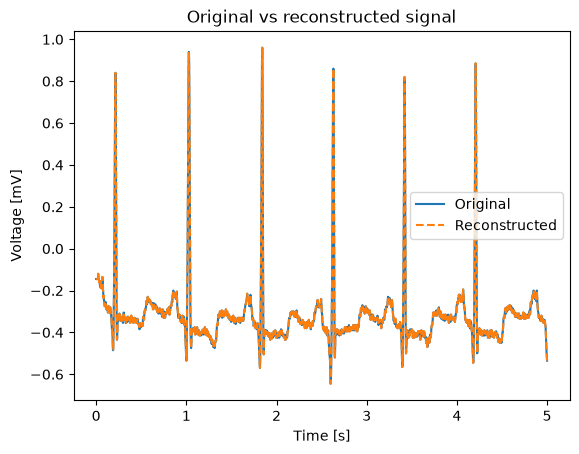

Saved figure: ./outputs\ecg_reconstruction_error.png


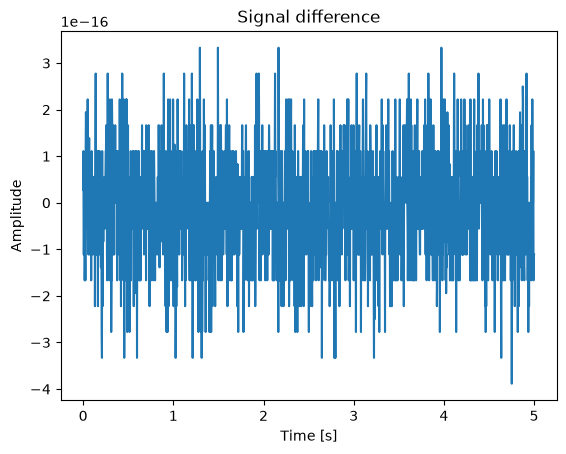

In [43]:
Y = np.fft.fft(ekg)
reconstructed = np.fft.ifft(Y)
difference = ekg - np.real(reconstructed)

plt.figure()
plt.title("Original vs reconstructed signal")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [mV]")
plt.plot(t[mask], ekg[mask], label="Original")
plt.plot(t[mask], np.real(reconstructed[mask]), label="Reconstructed", linestyle="--")
plt.legend()
save_figure("ecg_original_vs_reconstructed")

plt.figure()
plt.title("Signal difference")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.plot(t[mask], difference[mask])
save_figure("ecg_reconstruction_error")

The original and reconstructed signals overlap almost perfectly. The difference is on the order of $10^{-16}$, which is consistent with numerical floating-point error and is effectively zero for this application.

This confirms that the inverse FFT can reconstruct the original ECG signal when the complete Fourier spectrum is retained.

---

Butterworth low-pass and high-pass filters are applied to reduce power-line interference and baseline drift.

### 4.1 Inspect the Noisy Signal

The noisy ECG signal is loaded from `ekg_noise.txt`. The file contains two columns: time and amplitude, and the sampling frequency is $f_s = 360$ Hz.

Both the signal in the time domain and its amplitude spectrum are examined before filtering. This makes it possible to identify the characteristics and frequency components of the unwanted noise.

Saved figure: ./outputs\noisy_ecg.png


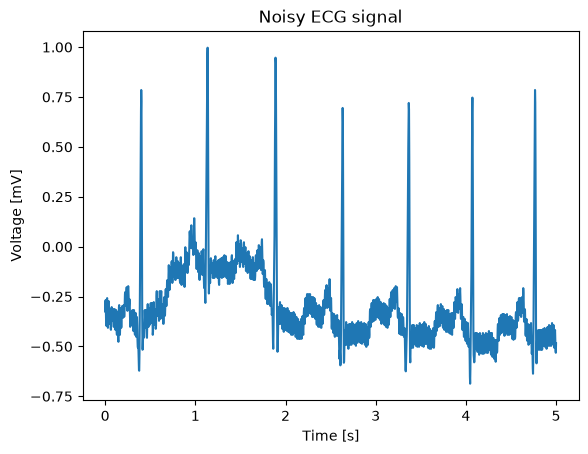

Saved figure: ./outputs\noisy_ecg_spectrum.png


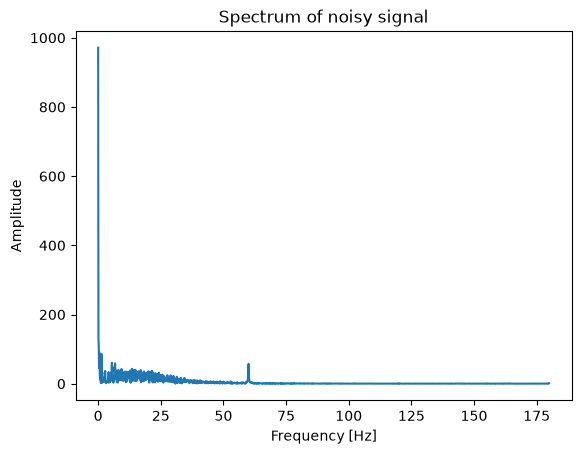

In [44]:
fs = 360

data = np.loadtxt('./signals/ekg_noise.txt')
t = data[:, 0]
ekg = data[:, 1]

mask = (t >= 0) & (t <= 5)

plt.figure()
plt.title("Noisy ECG signal")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [mV]")
plt.plot(t[mask], ekg[mask])
save_figure("noisy_ecg")

freqs = np.fft.fftfreq(len(ekg), 1/fs)
mask_freq = freqs >= 0

plt.figure()
plt.title("Spectrum of noisy signal")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(ekg))[mask_freq])
save_figure("noisy_ecg_spectrum")

The time-domain signal contains visible interference. In particular, the baseline slowly drifts over time, producing movement of the isoelectric line.

The amplitude spectrum also shows a pronounced peak around 60 Hz. This component is characteristic of power-line interference and motivates the use of a low-pass filter.

### 4.2 60 Hz Low-Pass Filter

A fourth-order Butterworth low-pass filter with a cutoff frequency of \(f_c = 60\) Hz is applied to reduce high-frequency interference, particularly the component associated with the power-line frequency.

The filter coefficients are calculated using `signal.butter()`. The `signal.filtfilt()` function is then used to apply the filter in both forward and backward directions. This avoids introducing a phase shift into the resulting signal.

The frequency response of the filter is also calculated using `signal.freqz()` to visualize its attenuation characteristics.

Saved figure: ./outputs\lowpass_60hz_response.png


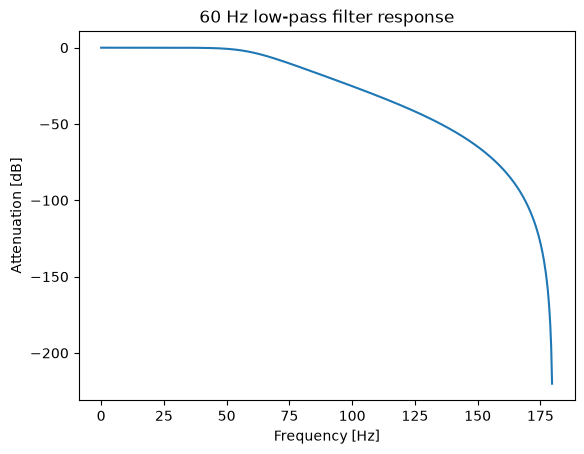

Saved figure: ./outputs\lowpass_filtered_ecg.png


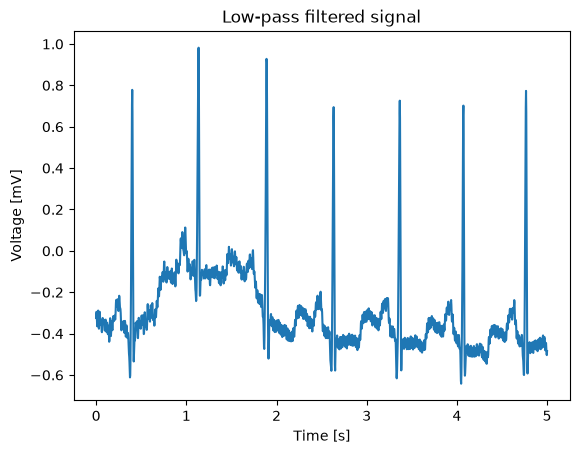

Saved figure: ./outputs\lowpass_filtered_spectrum.png


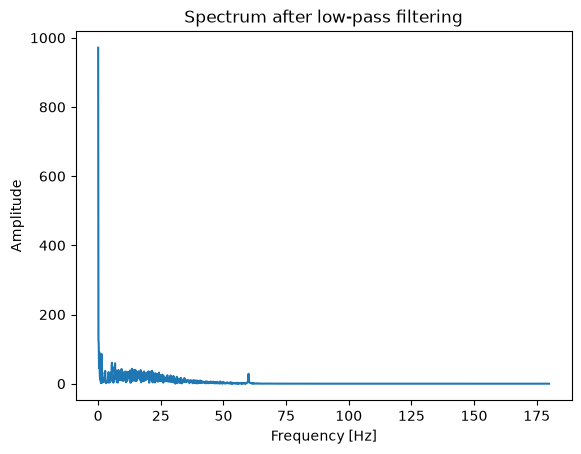

In [45]:
from typing import cast
from typing import Any

b, a = cast(
    tuple[np.ndarray, np.ndarray],
    signal.butter(4, 60, btype="low", fs=fs)
)
ekg_low = signal.filtfilt(b, a, ekg)

freqz = cast(Any, signal.freqz)
w, h = freqz(b=b, a=a, fs=float(fs))
plt.figure()
plt.title("60 Hz low-pass filter response")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Attenuation [dB]")
plt.plot(w, 20 * np.log10(abs(h)))
save_figure("lowpass_60hz_response")

plt.figure()
plt.title("Low-pass filtered signal")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [mV]")
plt.plot(t[mask], ekg_low[mask])
save_figure("lowpass_filtered_ecg")

plt.figure()
plt.title("Spectrum after low-pass filtering")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(ekg_low))[mask_freq])
save_figure("lowpass_filtered_spectrum")

The filter response shows increasing attenuation above the cutoff frequency of 60 Hz. After filtering, the component around 60 Hz is significantly reduced in the spectrum, while the time-domain ECG signal becomes smoother.

The low-pass filter therefore reduces rapidly varying components while preserving the lower-frequency structure of the ECG signal.

### 4.3 5 Hz High-Pass Filter

The low-pass filtered signal is subsequently processed using a fourth-order Butterworth high-pass filter with a cutoff frequency of $f_c$ = 5 Hz.

The purpose of the high-pass filter is to reduce slow baseline drift, also known as baseline wander or movement of the isoelectric line. Frequencies below 5 Hz are attenuated, while higher-frequency ECG components are preserved.

Saved figure: ./outputs\highpass_5hz_response.png


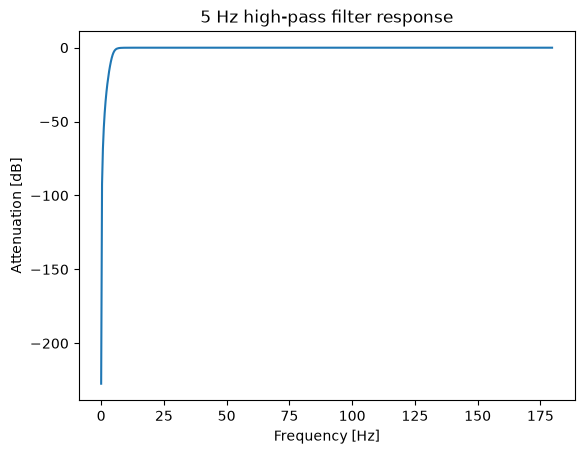

Saved figure: ./outputs\bandpass_filtered_ecg.png


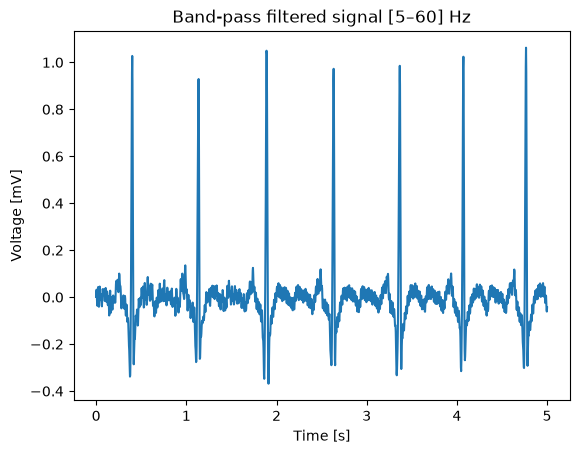

Saved figure: ./outputs\bandpass_filtered_spectrum.png


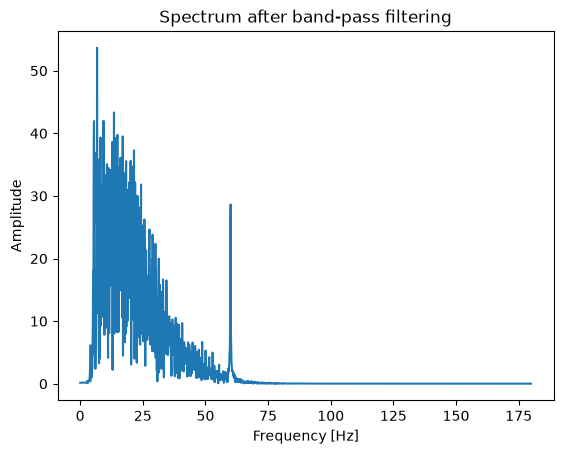

In [46]:
b2, a2 = cast(
    tuple[np.ndarray, np.ndarray],
    signal.butter(4, 5, btype="high", fs=fs)
)
ekg_band = signal.filtfilt(b2, a2, ekg_low)

w2, h2 = freqz(b=b2, a=a2, fs=float(fs))
plt.figure()
plt.title("5 Hz high-pass filter response")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Attenuation [dB]")
plt.plot(w2, 20 * np.log10(abs(h2)))
save_figure("highpass_5hz_response")

plt.figure()
plt.title("Band-pass filtered signal [5–60] Hz")
plt.xlabel("Time [s]")
plt.ylabel("Voltage [mV]")
plt.plot(t[mask], ekg_band[mask])
save_figure("bandpass_filtered_ecg")

plt.figure()
plt.title("Spectrum after band-pass filtering")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.plot(freqs[mask_freq], np.abs(np.fft.fft(ekg_band))[mask_freq])
save_figure("bandpass_filtered_spectrum")

The high-pass filter removes the slow variations of the baseline, resulting in a more stable isoelectric line.

Applying the 60 Hz low-pass filter followed by the 5 Hz high-pass filter is equivalent, in terms of the resulting passband, to applying a band-pass filter with a passband of approximately:

$$
[5,\ 60]\text{ Hz}.
$$

The final signal contains clearly visible QRS complexes, while low-frequency baseline drift and high-frequency interference have been substantially reduced. The spectrum confirms that the remaining signal energy is concentrated primarily within the selected passband.

## Conclusions

 The experiments demonstrated how ECG data can be loaded, visualized, transformed into the frequency domain, reconstructed, and filtered using Python and scientific computing libraries.

- **Task 1** focused on the test platform for loading, visualizing, and exporting ECG signals stored in different formats. An important part of the task was converting sample indices into time values using the sampling frequency $f_s$. This allowed the signals to be correctly interpreted and compared despite differences in their data formats.

- **Task 2** demonstrated the use of the discrete Fourier transform for frequency-domain analysis. For a single 50 Hz sinusoid, the amplitude spectrum contained one dominant peak at 50 Hz. For a signal composed of 50 Hz and 60 Hz sinusoids, two distinct spectral peaks were observed. This confirmed that the FFT can be used to identify individual frequency components of a signal. The inverse FFT also reconstructed the original signal with very high accuracy, with numerical errors close to machine precision.

- **Task 3** demonstrated the frequency-domain characteristics of a real ECG signal. Most of the signal energy was concentrated at low frequencies, which is consistent with the relatively slow variations of the cardiac cycle. The inverse FFT again reconstructed the original signal almost perfectly, with only negligible numerical differences.

- **Task 4** focused on digital filtering of a noisy ECG signal using Butterworth filters. The low-pass filter with a 60 Hz cutoff reduced high-frequency interference, including the prominent component around 60 Hz. The subsequent 5 Hz high-pass filter reduced baseline drift and stabilized the isoelectric line. Together, the filters formed an effective band-pass filtering stage with an approximate passband of 5–60 Hz.